In [72]:
import pandas as pd

df = pd.read_csv("output/merged_all_years.csv", parse_dates=True, index_col=0)
df.head()


,datetime_beginning_ept,nerc_region,mkt_region,zone,load_area,mw,is_verified,temperature_2m
2016-01-01 05:00:00,1/1/2016 12:00:00 AM,SERC,WEST,EKPC,EKPC,1485.000,True,4.4
2016-01-01 05:00:00,1/1/2016 12:00:00 AM,SERC,SOUTH,DOM,DOM,8549.125,True,4.4
2016-01-01 05:00:00,1/1/2016 12:00:00 AM,RTO,RTO,RTO,RTO,76169.255,True,4.4
2016-01-01 05:00:00,1/1/2016 12:00:00 AM,RFC,WEST,DUQ,DUQ,1376.868,True,4.4
2016-01-01 05:00:00,1/1/2016 12:00:00 AM,RFC,WEST,DEOK,DEOK,2732.349,True,4.4


In [73]:
df = df[['datetime_beginning_ept', 'load_area', 'mw', 'temperature_2m']].copy()
df.head()

,datetime_beginning_ept,load_area,mw,temperature_2m
2016-01-01 05:00:00,1/1/2016 12:00:00 AM,EKPC,1485.000,4.4
2016-01-01 05:00:00,1/1/2016 12:00:00 AM,DOM,8549.125,4.4
2016-01-01 05:00:00,1/1/2016 12:00:00 AM,RTO,76169.255,4.4
2016-01-01 05:00:00,1/1/2016 12:00:00 AM,DUQ,1376.868,4.4
2016-01-01 05:00:00,1/1/2016 12:00:00 AM,DEOK,2732.349,4.4


In [75]:
df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])
df['dow'] = df['datetime_beginning_ept'].dt.dayofweek

/var/folders/jn/yj91f36d1q5czmlvzf8lf2f40000gr/T/ipykernel_83327/3341078951.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])


In [76]:
# df already has df['dow'] = 0..6
df = pd.get_dummies(df, columns=['dow'], prefix='dow', dtype=float , drop_first=True)


In [77]:
df

,datetime_beginning_ept,load_area,mw,temperature_2m,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6
2016-01-01 05:00:00,2016-01-01 00:00:00,EKPC,1485.000,4.4,0.0,0.0,0.0,1.0,0.0,0.0
2016-01-01 05:00:00,2016-01-01 00:00:00,DOM,8549.125,4.4,0.0,0.0,0.0,1.0,0.0,0.0
2016-01-01 05:00:00,2016-01-01 00:00:00,RTO,76169.255,4.4,0.0,0.0,0.0,1.0,0.0,0.0
2016-01-01 05:00:00,2016-01-01 00:00:00,DUQ,1376.868,4.4,0.0,0.0,0.0,1.0,0.0,0.0
2016-01-01 05:00:00,2016-01-01 00:00:00,DEOK,2732.349,4.4,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
2025-10-31 03:00:00,2025-10-30 23:00:00,AEPIMP,3169.203,12.8,0.0,0.0,1.0,0.0,0.0,0.0
2025-10-31 03:00:00,2025-10-30 23:00:00,AEPAPT,3901.233,12.8,0.0,0.0,1.0,0.0,0.0,0.0
2025-10-31 03:00:00,2025-10-30 23:00:00,AECO,829.402,12.8,0.0,0.0,1.0,0.0,0.0,0.0
2025-10-31 03:00:00,2025-10-30 23:00:00,JC,2018.890,12.8,0.0,0.0,1.0,0.0,0.0,0.0


# Not useful

In [12]:
df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])
df_234 = df[df['datetime_beginning_ept'].dt.year.isin([2023, 2024, 2025])]


/var/folders/jn/yj91f36d1q5czmlvzf8lf2f40000gr/T/ipykernel_83327/2786285329.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])


In [14]:
df_234 = df_234[~df_234['load_area'].isin(['AE', 'RTO'])]
zones = df_234['load_area'].unique()
zones[0]


'PAPWR'

In [16]:
df_234['load_area'].value_counts()

load_area
PAPWR     24815
AEPIMP    24815
EKPC      24815
EASTON    24815
DUQ       24815
DPLCO     24815
DOM       24815
DEOK      24815
JC        24815
CE        24815
BC        24815
AP        24815
AEPOPT    24815
AEPKPT    24815
AEPAPT    24815
PE        24815
AECO      24815
ME        24815
OE        24815
PS        24815
OVEC      24815
VMEU      24815
SMECO     24815
RECO      24815
UGI       24815
PN        24815
PLCO      24815
PEPCO     24815
DAY       24815
Name: count, dtype: int64

In [17]:
zone0 = zones[0]
df_zone0 = df_234[df_234['load_area'] == zone0].copy()


In [18]:
df_zone0

,datetime_beginning_ept,load_area,mw,temperature_2m
2023-01-01 05:00:00,2023-01-01 00:00:00,PAPWR,447.210,10.9
2023-01-01 06:00:00,2023-01-01 01:00:00,PAPWR,433.960,10.8
2023-01-01 07:00:00,2023-01-01 02:00:00,PAPWR,431.361,11.2
2023-01-01 08:00:00,2023-01-01 03:00:00,PAPWR,418.749,10.8
2023-01-01 09:00:00,2023-01-01 04:00:00,PAPWR,431.029,9.9
...,...,...,...,...
2025-10-30 23:00:00,2025-10-30 19:00:00,PAPWR,554.769,16.0
2025-10-31 00:00:00,2025-10-30 20:00:00,PAPWR,546.890,15.8
2025-10-31 01:00:00,2025-10-30 21:00:00,PAPWR,520.535,15.1
2025-10-31 02:00:00,2025-10-30 22:00:00,PAPWR,506.842,13.8


In [19]:
df_zone0['datetime_beginning_ept'].value_counts()

datetime_beginning_ept
2024-11-03 01:00:00    2
2023-11-05 01:00:00    2
2024-11-20 14:00:00    1
2024-11-20 13:00:00    1
2024-11-20 12:00:00    1
                      ..
2023-12-11 14:00:00    1
2023-12-11 13:00:00    1
2023-12-11 12:00:00    1
2023-12-11 11:00:00    1
2025-10-30 23:00:00    1
Name: count, Length: 24813, dtype: int64

In [20]:
Tbase = 18.0
temp = df_zone0['temperature_2m']

df_zone0['CDD'] = (temp - Tbase).clip(lower=0)
df_zone0['HDD'] = (Tbase - temp).clip(lower=0)
df_zone0


,datetime_beginning_ept,load_area,mw,temperature_2m,CDD,HDD
2023-01-01 05:00:00,2023-01-01 00:00:00,PAPWR,447.210,10.9,0.0,7.1
2023-01-01 06:00:00,2023-01-01 01:00:00,PAPWR,433.960,10.8,0.0,7.2
2023-01-01 07:00:00,2023-01-01 02:00:00,PAPWR,431.361,11.2,0.0,6.8
2023-01-01 08:00:00,2023-01-01 03:00:00,PAPWR,418.749,10.8,0.0,7.2
2023-01-01 09:00:00,2023-01-01 04:00:00,PAPWR,431.029,9.9,0.0,8.1
...,...,...,...,...,...,...
2025-10-30 23:00:00,2025-10-30 19:00:00,PAPWR,554.769,16.0,0.0,2.0
2025-10-31 00:00:00,2025-10-30 20:00:00,PAPWR,546.890,15.8,0.0,2.2
2025-10-31 01:00:00,2025-10-30 21:00:00,PAPWR,520.535,15.1,0.0,2.9
2025-10-31 02:00:00,2025-10-30 22:00:00,PAPWR,506.842,13.8,0.0,4.2


In [21]:
y = df_zone0['mw']
exog = df_zone0[['CDD', 'HDD']]


In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y,
    order=(1,0,1),
    seasonal_order=(1,1,1,24),
    exog=exog,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

results = model.fit(disp=False)
results.summary()


/Users/seyonghw/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/seyonghw/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                 mw   No. Observations:                24815
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood             -104422.196
Date:                            Sat, 15 Nov 2025   AIC                         208858.392
Time:                                    17:16:20   BIC                         208915.213
Sample:                                01-01-2023   HQIC                        208876.792
                                     - 10-31-2025                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
CDD            2.5365      0.181     13.989      0.000       2.181       2.892
HDD            2.3399      0.191     12.224      0.000       1.965       2.715
ar.L1          0.9626      0.002    546.563      0.000       0.959       0.966
ma.L1         -0.0077      0.006     -1.327      0.185      -0.019       0.004
ar.S.L24       0.0886      0.007     13.173      0.000       0.075       0.102
ma.S.L24      -0.9257      0.003   -352.660      0.000      -0.931      -0.921
sigma2       268.6693      2.017    133.193      0.000     264.716     272.623
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               828.29
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.93   Skew:                            -0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y,
    order=(1,0,0),
    seasonal_order=(1,1,1,24),
    exog=exog,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

results = model.fit(disp=False)
results.summary()


/Users/seyonghw/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/seyonghw/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                   mw   No. Observations:                24815
Model:             SARIMAX(1, 0, 0)x(1, 1, [1], 24)   Log Likelihood             -104427.778
Date:                              Sat, 15 Nov 2025   AIC                         208867.556
Time:                                      17:20:17   BIC                         208916.259
Sample:                                  01-01-2023   HQIC                        208883.327
                                       - 10-31-2025                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
CDD            2.5267      0.182     13.909      0.000       2.171       2.883
HDD            2.3327      0.192     12.155      0.000       1.957       2.709
ar.L1          0.9621      0.002    563.199      0.000       0.959       0.965
ar.S.L24       0.0877      0.007     13.043      0.000       0.075       0.101
ma.S.L24      -0.9259      0.003   -353.271      0.000      -0.931      -0.921
sigma2       268.6783      2.016    133.300      0.000     264.728     272.629
===================================================================================
Ljung-Box (L1) (Q):                   1.49   Jarque-Bera (JB):               830.36
Prob(Q):                              0.22   Prob(JB):                         0.00
Heteroskedasticity (H):               0.93   Skew:                            -0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
fitted = results.fittedvalues  # same index as y used in model


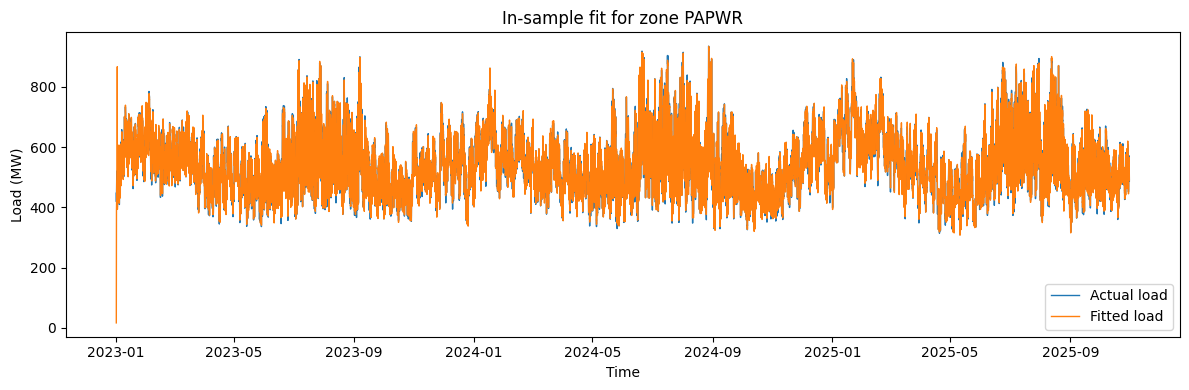

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(y, label='Actual load', linewidth=1)
plt.plot(fitted, label='Fitted load', linewidth=1)
plt.title(f"In-sample fit for zone {zone0}")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()


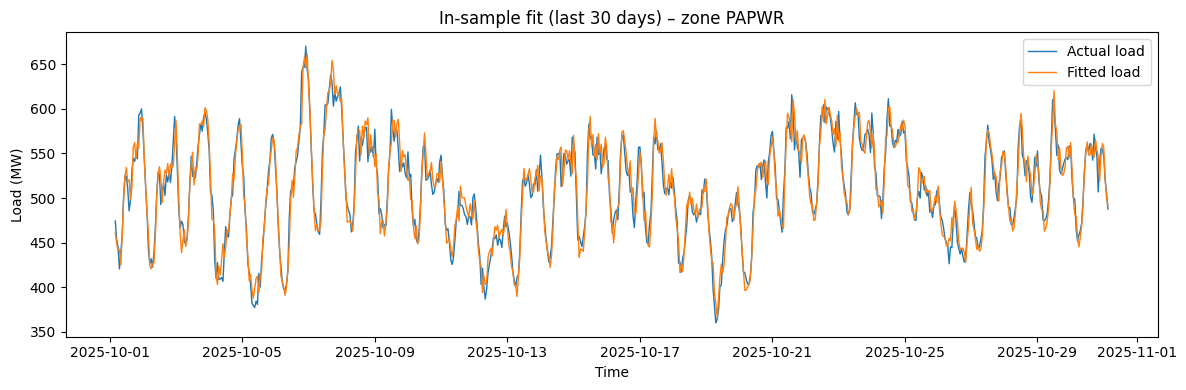

In [29]:
last_days = 24 * 30  # 30 days of hourly data
plt.figure(figsize=(12, 4))
plt.plot(y[-last_days:], label='Actual load', linewidth=1)
plt.plot(fitted[-last_days:], label='Fitted load', linewidth=1)
plt.title(f"In-sample fit (last 30 days) – zone {zone0}")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()


# Useful

In [78]:
zone = "EKPC"
df_zone = df[df['load_area'] == zone].copy()


In [79]:
Tbase = 18.0
temp = df_zone['temperature_2m']

df_zone['CDD'] = (temp - Tbase).clip(lower=0)
df_zone['HDD'] = (Tbase - temp).clip(lower=0)


In [80]:
df_zone

,datetime_beginning_ept,load_area,mw,temperature_2m,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,CDD,HDD
2016-01-01 05:00:00,2016-01-01 00:00:00,EKPC,1485.000,4.4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,13.6
2016-01-01 06:00:00,2016-01-01 01:00:00,EKPC,1482.000,4.1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,13.9
2016-01-01 07:00:00,2016-01-01 02:00:00,EKPC,1438.000,3.8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,14.2
2016-01-01 08:00:00,2016-01-01 03:00:00,EKPC,1464.000,3.7,0.0,0.0,0.0,1.0,0.0,0.0,0.0,14.3
2016-01-01 09:00:00,2016-01-01 04:00:00,EKPC,1446.000,3.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,14.5
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-30 23:00:00,2025-10-30 19:00:00,EKPC,1764.279,16.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0
2025-10-31 00:00:00,2025-10-30 20:00:00,EKPC,1666.102,15.8,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.2
2025-10-31 01:00:00,2025-10-30 21:00:00,EKPC,1637.072,15.1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.9
2025-10-31 02:00:00,2025-10-30 22:00:00,EKPC,1559.655,13.8,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.2


In [81]:
train = df_zone[df_zone['datetime_beginning_ept'].dt.year.isin([2021, 2022, 2023])]
test = df_zone[df_zone['datetime_beginning_ept'].dt.year == 2024]



In [86]:
train

,datetime_beginning_ept,load_area,mw,temperature_2m,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,CDD,HDD
2021-01-01 05:00:00,2021-01-01 00:00:00,EKPC,1672.649,-0.1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,18.1
2021-01-01 06:00:00,2021-01-01 01:00:00,EKPC,1636.030,-0.3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,18.3
2021-01-01 07:00:00,2021-01-01 02:00:00,EKPC,1633.819,-0.8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,18.8
2021-01-01 08:00:00,2021-01-01 03:00:00,EKPC,1613.055,-1.2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,19.2
2021-01-01 09:00:00,2021-01-01 04:00:00,EKPC,1612.926,-1.7,0.0,0.0,0.0,1.0,0.0,0.0,0.0,19.7
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 00:00:00,2023-12-31 19:00:00,EKPC,1904.961,2.5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.5
2024-01-01 01:00:00,2023-12-31 20:00:00,EKPC,1868.010,2.5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.5
2024-01-01 02:00:00,2023-12-31 21:00:00,EKPC,1869.876,1.9,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16.1
2024-01-01 03:00:00,2023-12-31 22:00:00,EKPC,1867.931,2.7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.3


In [90]:
exog_cols = ['CDD', 'HDD', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']

In [92]:
y_train = train['mw']
exog_train = train[exog_cols].copy()

model = SARIMAX(
    y_train,
    order=(1,0,0),
    seasonal_order=(1,1,1,24),  # daily seasonal pattern
    exog=exog_train,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())


/Users/seyonghw/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/seyonghw/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/seyonghw/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                                   mw   No. Observations:                26280
Model:             SARIMAX(1, 0, 0)x(1, 1, [1], 24)   Log Likelihood             -140753.717
Date:                              Sat, 15 Nov 2025   AIC                         281531.435
Time:                                      18:59:16   BIC                         281629.531
Sample:                                  01-01-2021   HQIC                        281563.112
                                       - 01-01-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
CDD            6.4296      0.597     10.765      0.000       5.259       7.600
HDD            7.61

In [93]:
exog_test = test[exog_cols]

y_pred_2024 = results.forecast(steps=len(test), exog=exog_test)


In [94]:
# In-sample fitted (2021–2023)
fitted_train = results.fittedvalues

# Combine everything
combined = pd.DataFrame({
    'Actual': df_zone['mw']['2021':'2024'],
    'Fitted_Train': fitted_train,      # 2021–2023 only
    'Forecast_2024': y_pred_2024       # 2024 only
})


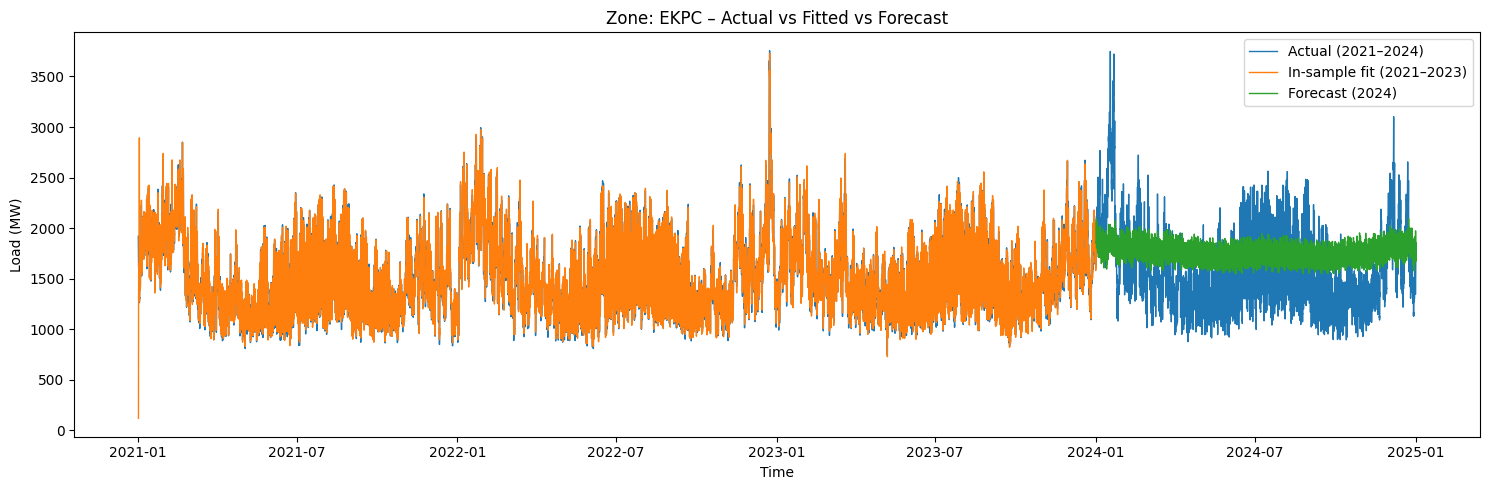

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(combined['Actual'], label='Actual (2021–2024)', linewidth=1)

plt.plot(combined['Fitted_Train'], 
         label='In-sample fit (2021–2023)', linewidth=1)

plt.plot(combined['Forecast_2024'], 
         label='Forecast (2024)', linewidth=1)

plt.title(f"Zone: {zone} – Actual vs Fitted vs Forecast")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()


In [99]:
train

,datetime_beginning_ept,load_area,mw,temperature_2m,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,CDD,HDD
2021-01-01 05:00:00,2021-01-01 00:00:00,EKPC,1672.649,-0.1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,18.1
2021-01-01 06:00:00,2021-01-01 01:00:00,EKPC,1636.030,-0.3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,18.3
2021-01-01 07:00:00,2021-01-01 02:00:00,EKPC,1633.819,-0.8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,18.8
2021-01-01 08:00:00,2021-01-01 03:00:00,EKPC,1613.055,-1.2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,19.2
2021-01-01 09:00:00,2021-01-01 04:00:00,EKPC,1612.926,-1.7,0.0,0.0,0.0,1.0,0.0,0.0,0.0,19.7
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 00:00:00,2023-12-31 19:00:00,EKPC,1904.961,2.5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.5
2024-01-01 01:00:00,2023-12-31 20:00:00,EKPC,1868.010,2.5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.5
2024-01-01 02:00:00,2023-12-31 21:00:00,EKPC,1869.876,1.9,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16.1
2024-01-01 03:00:00,2023-12-31 22:00:00,EKPC,1867.931,2.7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.3


In [102]:
train['hour'] = train['datetime_beginning_ept'].dt.hour
train

/var/folders/jn/yj91f36d1q5czmlvzf8lf2f40000gr/T/ipykernel_83327/3306046932.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['hour'] = train['datetime_beginning_ept'].dt.hour


,datetime_beginning_ept,load_area,mw,temperature_2m,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,CDD,HDD,hour
2021-01-01 05:00:00,2021-01-01 00:00:00,EKPC,1672.649,-0.1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,18.1,0
2021-01-01 06:00:00,2021-01-01 01:00:00,EKPC,1636.030,-0.3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,18.3,1
2021-01-01 07:00:00,2021-01-01 02:00:00,EKPC,1633.819,-0.8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,18.8,2
2021-01-01 08:00:00,2021-01-01 03:00:00,EKPC,1613.055,-1.2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,19.2,3
2021-01-01 09:00:00,2021-01-01 04:00:00,EKPC,1612.926,-1.7,0.0,0.0,0.0,1.0,0.0,0.0,0.0,19.7,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 00:00:00,2023-12-31 19:00:00,EKPC,1904.961,2.5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.5,19
2024-01-01 01:00:00,2023-12-31 20:00:00,EKPC,1868.010,2.5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.5,20
2024-01-01 02:00:00,2023-12-31 21:00:00,EKPC,1869.876,1.9,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16.1,21
2024-01-01 03:00:00,2023-12-31 22:00:00,EKPC,1867.931,2.7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,15.3,22


In [103]:
hourly_avg = train.groupby('hour')['mw'].mean()
hourly_avg

hour
0     1373.099925
1     1332.112002
2     1311.492525
3     1308.473227
4     1325.435484
5     1378.820445
6     1475.762372
7     1525.796883
8     1543.921205
9     1550.084388
10    1550.051777
11    1552.683554
12    1565.945268
13    1576.064616
14    1580.429724
15    1595.060740
16    1627.898994
17    1670.143633
18    1695.576080
19    1690.980447
20    1673.835045
21    1631.700487
22    1542.628758
23    1445.769933
Name: mw, dtype: float64

In [104]:
test['hour'] = test['datetime_beginning_ept'].dt.hour
baseline_pred = test['hour'].map(hourly_avg)
baseline_pred

/var/folders/jn/yj91f36d1q5czmlvzf8lf2f40000gr/T/ipykernel_83327/1849581732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['hour'] = test['datetime_beginning_ept'].dt.hour


2024-01-01 05:00:00    1373.099925
2024-01-01 06:00:00    1332.112002
2024-01-01 07:00:00    1311.492525
2024-01-01 08:00:00    1308.473227
2024-01-01 09:00:00    1325.435484
                          ...     
2025-01-01 00:00:00    1690.980447
2025-01-01 01:00:00    1673.835045
2025-01-01 02:00:00    1631.700487
2025-01-01 03:00:00    1542.628758
2025-01-01 04:00:00    1445.769933
Name: hour, Length: 8784, dtype: float64

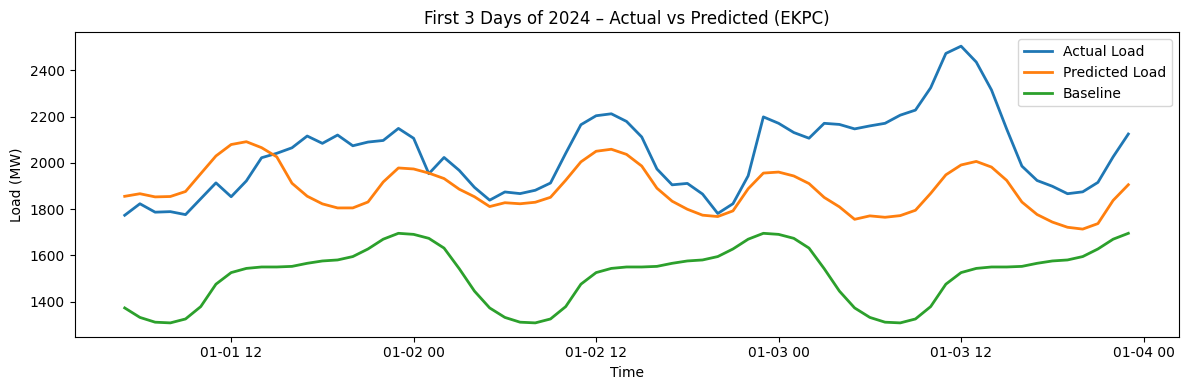

In [105]:
import matplotlib.pyplot as plt

# First 3 days of 2024
start_2024 = '2024-01-01'
end_3days = '2024-01-3 23:00:00'

actual_3 = test['mw'].loc[start_2024:end_3days]
pred_3 = y_pred_2024.loc[start_2024:end_3days]
baseline_3 = baseline_pred.loc[start_2024:end_3days]

plt.figure(figsize=(12,4))
plt.plot(actual_3, label="Actual Load", linewidth=2)
plt.plot(pred_3, label="Predicted Load", linewidth=2)
plt.plot(baseline_3, label="Baseline", linewidth=2)

plt.title(f"First 3 Days of 2024 – Actual vs Predicted ({zone})")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()


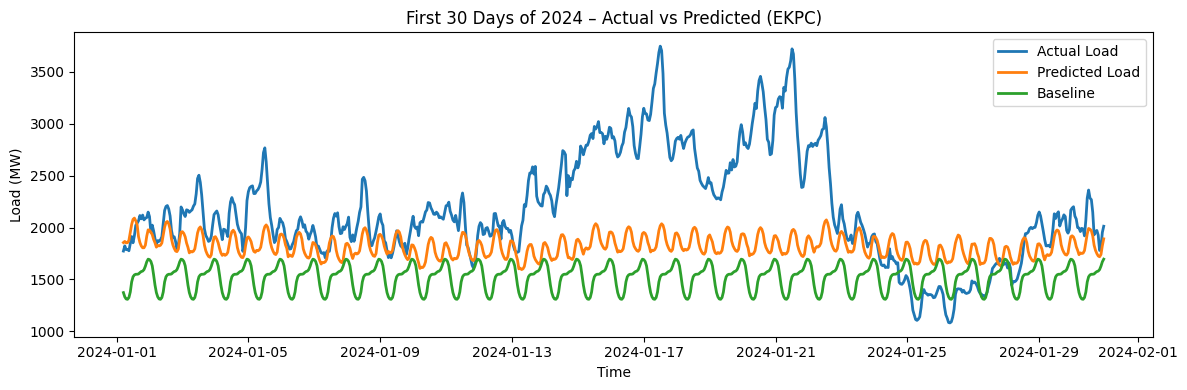

In [107]:
# First 30 days of 2024
start_2024 = '2024-01-01'
end_30days = '2024-01-30 23:00:00'

actual_30 = test['mw'].loc[start_2024:end_30days]
pred_30 = y_pred_2024.loc[start_2024:end_30days]
baseline_30 = baseline_pred.loc[start_2024:end_30days]

plt.figure(figsize=(12,4))
plt.plot(actual_30, label="Actual Load", linewidth=2)
plt.plot(pred_30, label="Predicted Load", linewidth=2)
plt.plot(baseline_30, label="Baseline", linewidth=2)

plt.title(f"First 30 Days of 2024 – Actual vs Predicted ({zone})")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()
